# Download

In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

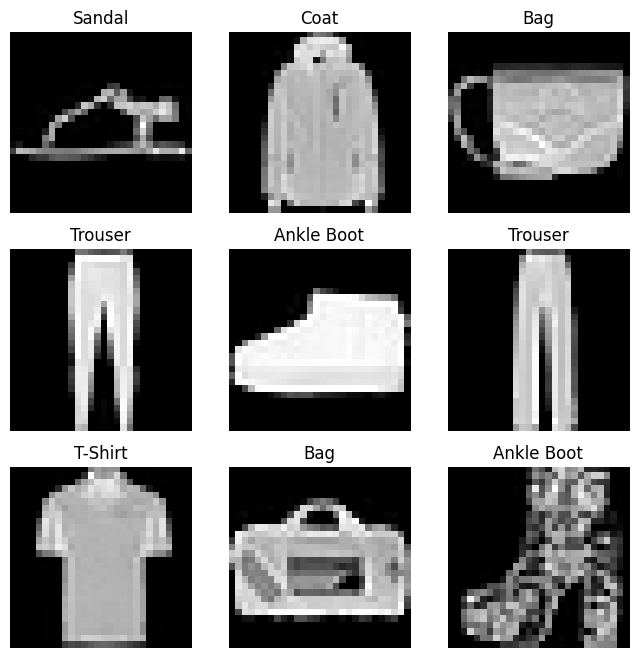

In [4]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()  # get random index
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")  # img.squeeze()は(1,28,28) -> (28,28)
plt.show()




# Create a Custom Dataset

In [5]:
import os
import pandas as pd
from torchvision.io import decode_image  # io: ファイルの読み書き、decode_image: 画像の0,1データをテンソルに変換


class CustomImageDataset(Dataset):
        def __init__(self, annotation_file, img_dir, transform=None, target_transform=None):
            self.img_labeles = pd.read_csv(annotation_file)
            self.img_dir = img_dir
            self.transform = transform
            self.target_transform = target_transform

        def __len__(self):
            return len(self.img_labels)

        def __getitem__(self, idx):
            img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
            image = decode_image(img_path)
            label = self.img_labels.iloc[idx, 1]
            if self.transform:
                image = self.transform(image)  # 画像の前処理、リサイズなど
            if self.target_transform:
                label = self.target_transform(label)  # ラベルの前処理、one-hot encodingなど
            return image, label

# Dataloader

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)  # training_data = datasets.FashionMNIST(公式が提供するデータセットクラス)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


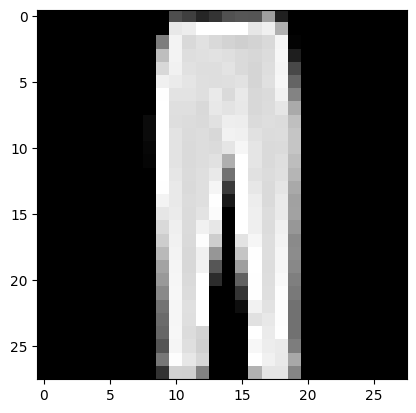

Label: 1


In [7]:
# Display image and label
train_features, train_labels = next(iter(train_dataloader))
print(f"feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

# additional problems from gemini

torch.Size([1, 28, 28])
9


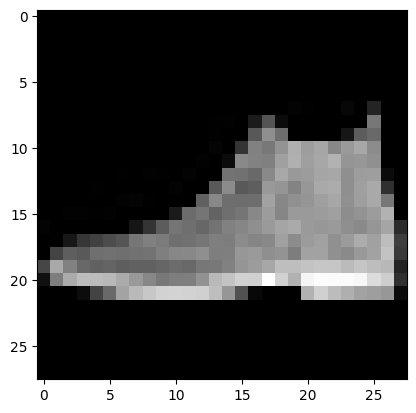

In [8]:
# load test data from torchvision
image, label = test_data[0]
print(image.shape)
print(label)

image = image.squeeze()
plt.imshow(image, cmap="gray")
plt.show()

### データをダウンロード
curl -O https://download.pytorch.org/tutorial/hymenoptera_data.zip

### 解凍 (Mac/Linux)
unzip hymenoptera_data.zip

In [24]:
import os
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import glob

# dataset class
class Hymenoptera(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []

        ants_files = glob.glob(os.path.join(root_dir, "ants", "*.jpg"))
        self.image_paths += ants_files
        self.labels += [0] * len(ants_files)

        bees_files = glob.glob(os.path.join(root_dir, "bees", "*.jpg"))
        self.image_paths += bees_files
        self.labels += [1] * len(bees_files)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


# data preprocessing
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


hymenoptera = Hymenoptera("../data/hymenoptera_data/train", data_transform)


In [25]:
len(hymenoptera)

243

torch.Size([4, 3, 128, 128])
torch.Size([4])


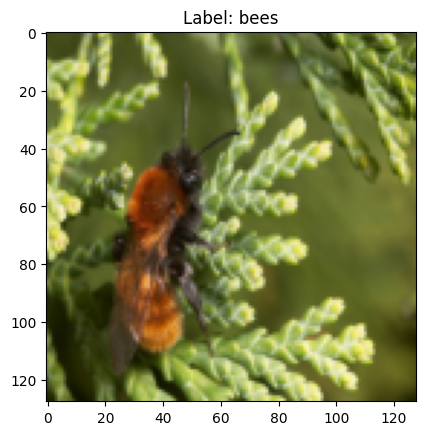

In [33]:
from torch.utils.data import DataLoader

# Dataloader
train_dataloader = DataLoader(hymenoptera, batch_size=4, shuffle=True)

images, labels = next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

# define labels
class_names = ["ants", "bees"]

# visualize first image
first_image = images[0]  # torch.Size([3, 128, 128]) C, H, W
first_image = first_image.permute(1, 2, 0)  # C, H, W => H, W, C

first_label = labels[0]
first_label = class_names[first_label]
plt.imshow(first_image)
plt.title(f"Label: {first_label}")
plt.show()